**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# 5. Non-linear economy: the restricted NARX networks

The paper's non-linear environment: each transition equation is a single-hidden-layer network on the
same restricted inputs as the linear benchmark, trained by Levenberg-Marquardt with the number of
hidden units chosen on a validation block (Hinterlang & Tänzer, 2021, Section 2.1.1).

**Inputs:** `artifacts/data/`, `artifacts/linear/one_step_fixed.csv` (the SVAR fits, for comparison).
**Outputs:** `artifacts/nonlinear/narx.pt` (networks, scalers and shock scales, for the
reinforcement-learning notebooks) and `artifacts/nonlinear/one_step_narx.csv`.

The classes and functions the text describes (the scaler, the initialisation, the network, the trainers,
the search) are defined in `autofed.nonlinear`; this notebook configures and calls them.

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import autofed as af
from autofed import linear as lin
from autofed import nonlinear as nl
from autofed import plots
from autofed.style import COLORS

nb = af.NotebookSession(
    "05_nonlinear_narx", number=5, title="Non-linear economy: the restricted NARX networks"
)
panel = af.load_macro_panel(nb.artifacts("data"))
cfg = panel.config
df_train, df_all = panel.train, panel.full
svar_fit = af.load_frame(
    nb.artifacts("linear") / "one_step_fixed.csv", producer="notebook 01_linear_svar"
)
print(
    f"Data vintage {panel.retrieved} | training {df_train.index[0]}-{df_train.index[-1]} | "
    f"full {df_all.index[0]}-{df_all.index[-1]} | torch {torch.__version__}"
)


def squared(frame: pd.DataFrame, column: str) -> pd.Series:
    return (frame[column] - frame[f"{column}_hat"]) ** 2


def mse_row(frame: pd.DataFrame) -> dict[str, float]:
    mse_y, mse_pi = float(squared(frame, "y").mean()), float(squared(frame, "pi").mean())
    return {
        "MSE output gap": mse_y,
        "MSE inflation": mse_pi,
        "MSE total": 0.5 * (mse_y + mse_pi),
    }

Data vintage 2026-10-07 | training 1987Q3-2007Q2 | full 1987Q3-2026Q2 | torch 2.14.1


## Motivation and relation to the linear benchmark

The nonlinear environment is designed as the ANN analogue of the restricted linear benchmark. In the linear notebook, the baseline recursive SVAR(2) is first estimated in full and then restricted by dropping statistically weak second-lag terms. The resulting restricted system is then used as the compact benchmark environment.

Accordingly, the nonlinear environment should preserve that same reduced information structure so that the linear and nonlinear environments remain directly comparable.

## Corrected nonlinear transition equations

Let $y_t$ denote the output gap, $\pi_t$ inflation, and $i_t$ the policy rate. After applying the lag restrictions from the linear environment, the nonlinear economy is written as follows.

### Output-gap equation

The output-gap network uses only first-lag regressors:

$$
y_t = \hat f_y\!\left(y_{t-1}, \pi_{t-1}, i_{t-1}\right) + \varepsilon_t^y
$$

This matches the restricted linear output-gap equation, where the retained nonzero terms are the constant, $y_{t-1}$, $\pi_{t-1}$, and $i_{t-1}$, while $y_{t-2}$, $\pi_{t-2}$, and $i_{t-2}$ are dropped.

### Inflation equation

The inflation network retains contemporaneous output and the restricted lag structure:

$$
\pi_t = \hat f_\pi\!\left(y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}\right) + \varepsilon_t^\pi
$$

This matches the restricted linear inflation equation, where $i_{t-2}$ is dropped but $y_t$, $y_{t-1}$, $y_{t-2}$, $\pi_{t-1}$, $\pi_{t-2}$, and $i_{t-1}$ remain.

### Conditional interpretation

Because the inflation equation includes contemporaneous $y_t$, the inflation network is recursive or triangular in the same sense as the linear notebook’s inflation equation. Therefore:

- conditional one-step inflation predictions should use realized $y_t$
- fully recursive simulation would instead substitute $\hat y_t$

This distinction should remain explicit throughout the nonlinear notebook.

## Data source, sample, and observables

The nonlinear environment uses the same quarterly macroeconomic panel as the linear benchmark so that nonlinear and linear results remain directly comparable. The sample definition, variable construction, and frequency treatment are therefore unchanged relative to the restricted linear environment.

### Sample window

The estimation sample is 1987Q3–2007Q2. This is the same pre-crisis training window used in the linear notebook and is retained here so that the nonlinear environment is estimated on the exact same historical information set.

### Frequency

All series are used at quarterly frequency. When the underlying raw series are available at higher frequency, they are aggregated to quarters before model construction.

### Observables

We use the same three observables as in the linear benchmark:

- inflation, $\pi_t$: year-over-year percent change in the GDP implicit price deflator
- output gap, $y_t$: percent deviation of real GDP from potential GDP
- policy rate, $i_t$: quarterly average of the effective federal funds rate

This ensures that any performance difference between the linear and nonlinear environments is attributable to the functional form and estimation procedure rather than to a different data construction pipeline.

### Variable definitions

Inflation is defined as

$$
\pi_t = 100\left(\frac{P_t}{P_{t-4}} - 1\right),
$$

where $P_t$ is the GDP implicit price deflator.

The output gap is defined as

$$
y_t = 100\left(\frac{Y_t}{Y_t^*} - 1\right),
$$

where $Y_t$ is real GDP and $Y_t^*$ is potential GDP.

The policy indicator $i_t$ is the effective federal funds rate aggregated to the quarterly frequency by averaging within quarter.

### Data replication from the linear notebook

Because the nonlinear notebook is built as the ANN counterpart to the linear environment, it replicates the same merged quarterly dataset from the linear notebook. Even so, the data are rechecked here so that the nonlinear notebook remains self-contained and fully auditable on its own.

## NARX architecture

The nonlinear transition equations are approximated using shallow feedforward neural networks in a NARX (Nonlinear AutoRegressive with eXogenous inputs) framework. NARX models are a standard approach for modeling nonlinear dynamic systems with lagged endogenous and exogenous inputs (Chen & Billings, 1992; Narendra & Parthasarathy, 1990).

For each equation $m \in \{y,\pi\}$, define

$$
\hat f_m(s_t^m)
=
b_{0}^{m}
+
\sum_{j=1}^{h_m}
v_j^{m}\,
G\!\left((w_j^{m})' s_t^m + b_j^{m}\right),
$$

where:

- $s_t^y = (y_{t-1}, \pi_{t-1}, i_{t-1})$
- $s_t^\pi = (y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1})$
- $h_m$ is the number of hidden neurons in equation $m$
- $w_j^m$ is the hidden-layer weight vector
- $b_j^m$ is the hidden-layer bias
- $v_j^m$ is the output-layer weight
- $b_0^m$ is the output-layer bias

The activation function is the hyperbolic tangent:

$$
G(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}.
$$

The tanh activation is commonly used in shallow networks due to its smoothness and favorable optimization properties relative to piecewise-linear alternatives in small-sample settings (LeCun et al., 2012). The network is intentionally kept shallow so that it remains comparable to the linear benchmark and so that Levenberg–Marquardt estimation remains computationally feasible.

## Numerical implementation choices

### Float64 and CPU execution

To better replicate the numerical behavior of the reference MATLAB implementation, tensors are evaluated in double precision (`torch.float64`). On the local ARM64 MacBook Pro environment, this implies CPU-based training rather than MPS acceleration because MPS does not support float64. This tradeoff favors numerical fidelity over raw speed and is appropriate for the small-network, replication-oriented setting considered here.

### Determinism

For reproducibility, deterministic PyTorch algorithms are enabled so that repeated runs under the same seed and software environment produce stable results whenever possible. This is particularly important because initialization and nonlinear optimization materially affect ANN estimates.

In [19]:
DTYPE = torch.float64
DEVICE = torch.device("cpu")
torch.use_deterministic_algorithms(True)

## Utility helpers

Before constructing the nonlinear model, `autofed.nonlinear` defines a small set of internal helper functions to standardize tensor handling. These helpers enforce two-dimensional input shapes, check for non-finite values, flatten parameter collections into a single vector, and reassign flat parameter vectors back into model weights. This machinery is necessary because the Levenberg–Marquardt optimizer operates directly on vectorized parameters and Jacobian matrices rather than using PyTorch’s standard first-order optimizer interface.

## Input scaling: PyTorch-native `mapminmax`

The nonlinear environment uses a PyTorch-native implementation of MATLAB’s `mapminmax` transformation. Each feature is scaled independently from its observed sample range to a user-specified target interval, with default range $[-1,1]$. For `tanh` networks, this is the natural normalization because it places the regressors in the region where the activation function remains most responsive. Constant columns are handled separately so that division-by-zero issues are avoided and their transformed values remain well-defined.

For feature $x_j$, the transformation is

$$
x_{j,\mathrm{scaled}}
=
a
+
\frac{x_j - x_j^{\min}}{x_j^{\max} - x_j^{\min}}
(b-a),
$$

where $[a,b]$ is the target interval, here typically $[-1,1]$.

Because the two equations use different regressor sets, the nonlinear environment should later fit separate input and target scalers for each equation.

## Nguyen–Widrow initialization

To replicate the reference neural-network setup more closely, hidden-layer parameters are initialized using the Nguyen–Widrow method (Nguyen & Widrow, 1990). This initialization is designed for shallow feedforward networks with bounded nonlinear activations such as `tanh`. Its purpose is to distribute hidden neurons across the informative region of the activation function at the start of training, reducing the risk that many neurons begin in heavily saturated regions where local sensitivity is weak.

Let $w_i^0$ be the preliminary weight vector for hidden unit $i$, drawn from a uniform distribution. Nguyen–Widrow rescales this vector as

$$
w_i
=
\beta \frac{w_i^0}{\|w_i^0\|},
\qquad
b_i \sim U[-\beta,\beta],
\qquad
\beta = 0.7\, n_{\text{out}}^{1/n_{\text{in}}}.
$$

## NARX network class

The `NARXNet` class implements a shallow feedforward approximation to each nonlinear transition equation. Given an input vector $x_t$, the forward map is

$$
\hat x_t = W_2 \tanh(W_1 x_t + b_1) + b_2.
$$

The same architecture is used for both equations, but with equation-specific input dimensions and hidden-unit counts. In the present notebook:

- output-gap network: `input_size = 3`
- inflation network: `input_size = 6`

This reflects the restricted lag structure inherited from the linear benchmark.

## Levenberg–Marquardt trainer

The nonlinear environment is trained using a Levenberg–Marquardt (LM) algorithm, a second-order optimization method originally developed for nonlinear least squares problems (Levenberg, 1944; Marquardt, 1963). Unlike first-order methods such as stochastic gradient descent or Adam, LM explicitly uses the Jacobian of residuals to construct a local quadratic approximation to the loss function. This makes it particularly well-suited for small neural networks trained in batch settings (Hagan & Menhaj, 1994).

Let $e$ denote the residual vector and $J$ the Jacobian of residuals with respect to the stacked parameter vector. The update is

$$
\Delta w = -(J^\top J + \mu I)^{-1} J^\top e,
$$

where $\mu$ is the damping parameter. When a trial step improves the loss, $\mu$ is reduced; when it does not, $\mu$ is increased. This allows the optimizer to interpolate between Gauss–Newton behavior and more conservative damped updates.

Because the method forms the full Jacobian explicitly, it is best suited to the small-network, full-batch setting considered here.

## Hidden-unit selection and validation design

The number of hidden units $h$ is treated as a hyperparameter and selected using a train-validation split. Following the reference procedure, the sample is divided so that the last 15% of observations are reserved for validation and are not used for parameter updating during training.

For each candidate hidden size $h \in \{1,\dots,10\}$, the network is initialized 30 separate times using different random seeds. For each trial, the model is trained on the training sample and evaluated on the validation sample. The chosen hidden size is the one with the lowest validation mean squared error averaged across the 30 trials.

To limit overfitting, training uses an early stopping rule based on validation performance. Specifically, training stops when validation mean squared error fails to improve for six consecutive epochs. After the optimal hidden size is fixed, the final retained initialization is the one that yields the lowest overall mean squared error among the 30 trials for that hidden size.

This model-selection protocol preserves the reference paper’s hidden-search logic while keeping the nonlinear environment aligned with the restricted regressor structure inherited from the linear benchmark.

The model-selection strategy—averaging validation performance across multiple random initializations—is consistent with standard neural-network model selection practices and closely follows the approach of Aras and Kocakoç (2016).

Validation-based early stopping is used to prevent overfitting by halting training when validation performance fails to improve.

This approach aligns with a broader literature replacing linear macroeconomic transition equations with nonlinear function approximators, including neural networks and state-space models (White, 1988; Swanson & White, 1997).

## Restricted NARX design matrices

The nonlinear environment uses the lag-dropped regressor sets from the restricted linear environment.

For the output-gap equation:

$$
y_t = \hat f_y(y_{t-1}, \pi_{t-1}, i_{t-1}) + \varepsilon_t^y
$$

For the inflation equation:

$$
\pi_t = \hat f_\pi(y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}) + \varepsilon_t^\pi
$$

Accordingly, the design matrices are built equation-by-equation rather than from the older unrestricted lag layout.

## Train-validation split

Following the reference procedure, the last 15% of observations are reserved for validation. Because this is a time-series setting, the split is chronological rather than random. This preserves temporal ordering and prevents leakage from future observations into the training sample.

## Validation-aware Levenberg–Marquardt training with early stopping

The hidden search requires validation-based early stopping. Training therefore monitors validation MSE after each epoch and stops when validation performance fails to improve for six consecutive epochs.

Because the network is small and the estimation is full-batch, this validation-aware extension remains compatible with the Levenberg–Marquardt framework implemented above.

## Hidden search routines

The hidden search is performed separately for the output-gap and inflation equations. For each candidate hidden size:

1. build the equation-specific training and validation split,
2. scale inputs and targets using training-sample information only,
3. run 30 random initializations,
4. train each trial with Levenberg–Marquardt and validation-based early stopping,
5. compute validation MSE,
6. average validation MSE across the 30 trials.

The selected hidden size is the one with the lowest average validation MSE.

After fixing the chosen hidden size, the retained initialization is the trial with the lowest overall mean squared error.

## Build design matrices and run the hidden search

The next cells instantiate the restricted design matrices and run the hidden search separately for the output-gap and inflation equations.

By construction:

- the output-gap network searches over an input dimension of 3,
- the inflation network searches over an input dimension of 6.

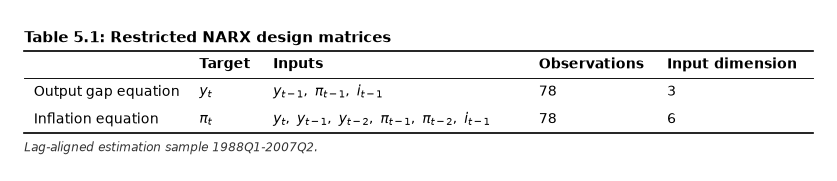

In [20]:
design = nl.build_restricted_narx_design_matrices(df_train, dtype=DTYPE, device=DEVICE)
design_table = pd.DataFrame({
    "Output gap equation": {
        "Target": r"$y_t$",
        "Inputs": r"$y_{t-1},\ \pi_{t-1},\ i_{t-1}$",
        "Observations": design.X_y.shape[0],
        "Input dimension": design.X_y.shape[1],
    },
    "Inflation equation": {
        "Target": r"$\pi_t$",
        "Inputs": r"$y_t,\ y_{t-1},\ y_{t-2},\ \pi_{t-1},\ \pi_{t-2},\ i_{t-1}$",
        "Observations": design.X_pi.shape[0],
        "Input dimension": design.X_pi.shape[1],
    },
}).T
nb.table(
    design_table,
    "narx_design",
    "Restricted NARX design matrices",
    note=f"Lag-aligned estimation sample {design.time_index[0]}-{design.time_index[-1]}.",
)

In [21]:
HIDDEN_MIN, HIDDEN_MAX = 1, 10  # candidate hidden-layer sizes
N_TRIALS = 30  # random initialisations per size (600 fits in all)
PATIENCE = 6  # early stopping: epochs without validation improvement
MAX_EPOCHS = 200
VAL_FRACTION = 0.15  # last block of the sample, chronological
SEED_Y, SEED_PI = 123, 456

search_kwargs = {
    "time_index": design.time_index,
    "hidden_min": HIDDEN_MIN,
    "hidden_max": HIDDEN_MAX,
    "n_trials": N_TRIALS,
    "patience": PATIENCE,
    "max_epochs": MAX_EPOCHS,
    "val_fraction": VAL_FRACTION,
    "dtype": DTYPE,
    "device": DEVICE,
}
hidden_search_y = nl.run_hidden_unit_search(
    equation_name="Output gap",
    X=design.X_y,
    y=design.y_target,
    base_seed=SEED_Y,
    **search_kwargs
)
hidden_search_pi = nl.run_hidden_unit_search(
    equation_name="Inflation",
    X=design.X_pi,
    y=design.pi_target,
    base_seed=SEED_PI,
    **search_kwargs
)
SEARCHES = (("Output gap equation", hidden_search_y), ("Inflation equation", hidden_search_pi))

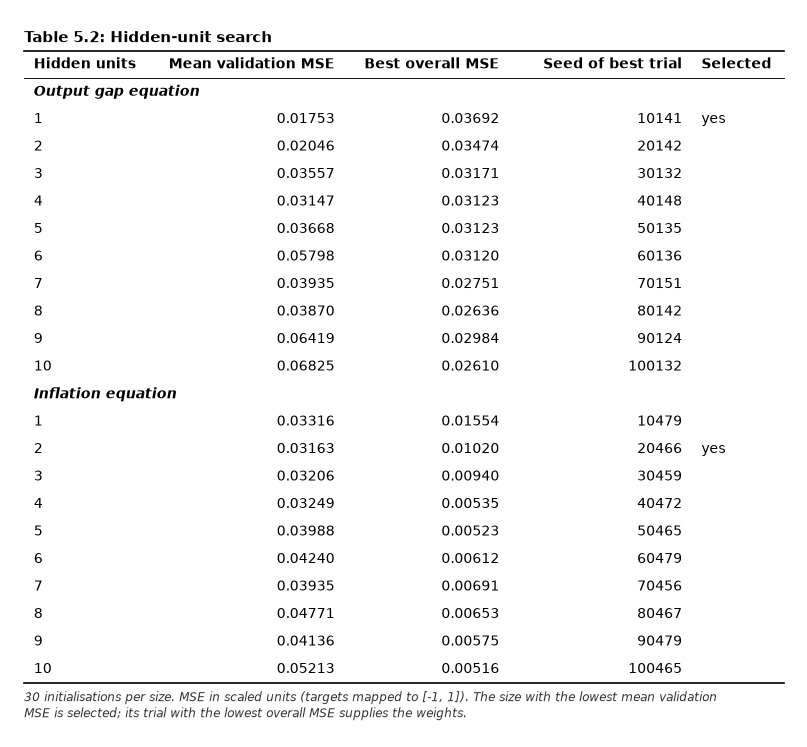

In [22]:
rows = {}
for label, search in SEARCHES:
    for size, mean_val in search.mean_val_mse_by_hidden.items():
        best = search.best_trial_by_hidden[size]
        rows[(label, str(size))] = {
            "Mean validation MSE": mean_val,
            "Best overall MSE": best.overall_mse,
            "Seed of best trial": best.trial_seed,
            "Selected": "yes" if size == search.selected_hidden_size else "",
        }
search_table = pd.DataFrame.from_dict(rows, orient="index")
search_table.index = pd.MultiIndex.from_tuples(
    search_table.index, names=["Equation", "Hidden units"]
)
nb.table(
    search_table,
    "hidden_unit_search",
    "Hidden-unit search",
    float_format="{:.5f}",
    note=(
        f"{N_TRIALS} initialisations per size. MSE in scaled units (targets mapped to [-1, 1])."
        " The size with the lowest mean validation MSE is selected; its trial with the lowest"
        " overall MSE supplies the weights."
    ),
)

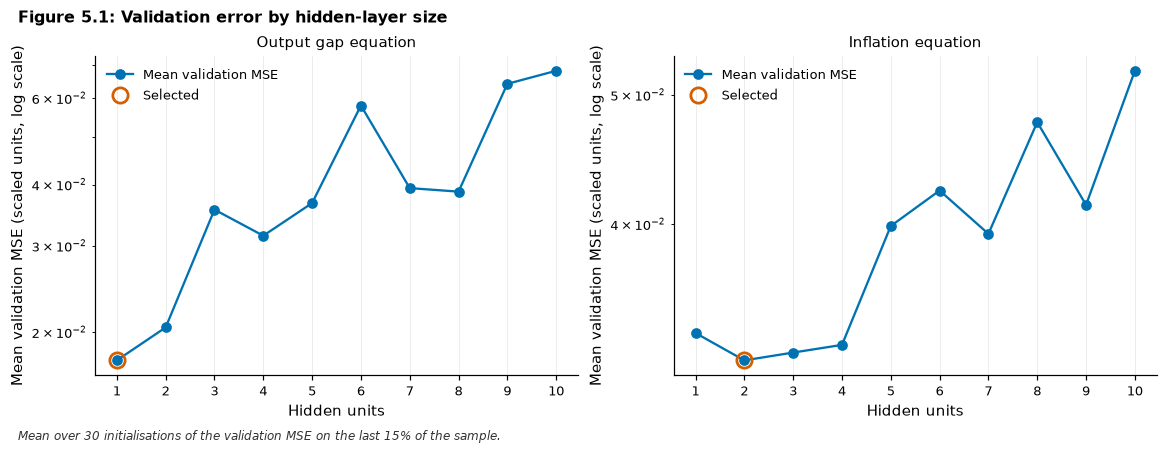

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for ax, (label, search) in zip(axes, SEARCHES):
    sizes = list(search.mean_val_mse_by_hidden)
    values = [search.mean_val_mse_by_hidden[s] for s in sizes]
    ax.plot(sizes, values, marker="o", color=COLORS["blue"], label="Mean validation MSE")
    ax.plot(
        [search.selected_hidden_size],
        [search.mean_val_mse_by_hidden[search.selected_hidden_size]],
        marker="o",
        ms=10,
        mfc="none",
        mec=COLORS["vermillion"],
        mew=1.8,
        ls="none",
        label="Selected",
    )
    ax.set_yscale("log")
    ax.set_xticks(sizes)
    ax.set_title(label)
    ax.set_xlabel("Hidden units")
    ax.set_ylabel("Mean validation MSE (scaled units, log scale)")
    ax.legend()
nb.figure(
    fig,
    "hidden_unit_selection",
    "Validation error by hidden-layer size",
    note=(
        f"Mean over {N_TRIALS} initialisations of the validation MSE on the last"
        f" {VAL_FRACTION:.0%} of the sample."
    ),
)

## Final model instantiation

After selecting the optimal hidden-unit count for each equation, the final nonlinear environment is instantiated using the retained initialization that produced the lowest overall mean squared error for that hidden size.

Thus, the final output-gap network uses:

- the selected hidden size for the $y_t$ equation,
- the retained random initialization for that hidden size,
- the associated input and target scalers fitted on the training portion of the sample.

The same procedure is applied to the inflation network.

## Build final equation-specific networks

The final output-gap and inflation networks are now instantiated with the selected hidden sizes. Their retained weights and biases are loaded from the best trial found during the hidden search.

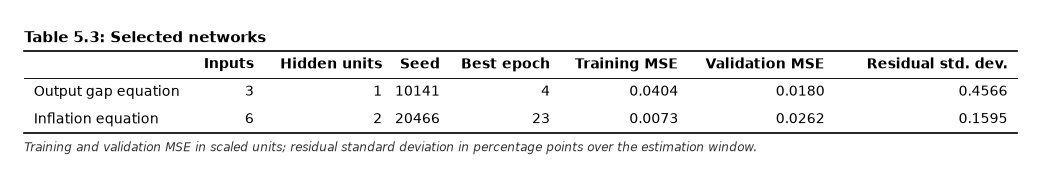

In [24]:
economy = nl.NARXEconomy.from_search(
    hidden_search_y,
    hidden_search_pi,
    dtype=DTYPE,
    device=DEVICE,
    sample=f"{cfg.train_start}-{cfg.train_end}",
    vintage=panel.retrieved,
)
fit_all = economy.predict(df_all)  # one-step fits on realised lags, estimation + out-of-sample
fit_narx = fit_all.loc[: cfg.train_end]
economy.set_sigma(fit_narx)  # residual standard deviations over the estimation window

selected = {}
for label, search, net, sigma in (
    ("Output gap equation", hidden_search_y, economy.net_y, economy.sigma_y),
    ("Inflation equation", hidden_search_pi, economy.net_pi, economy.sigma_pi),
):
    trial = search.best_trial_by_hidden[search.selected_hidden_size]
    selected[label] = {
        "Inputs": net.input_size,
        "Hidden units": net.hidden_size,
        "Seed": trial.trial_seed,
        "Best epoch": trial.best_epoch,
        "Training MSE": trial.train_mse,
        "Validation MSE": trial.val_mse,
        "Residual std. dev.": sigma,
    }
selected = pd.DataFrame(selected).T.astype(
    {"Inputs": int, "Hidden units": int, "Seed": int, "Best epoch": int}
)
nb.table(
    selected,
    "selected_networks",
    "Selected networks",
    float_format="{:.4f}",
    note=(
        "Training and validation MSE in scaled units; residual standard deviation in percentage"
        " points over the estimation window."
    ),
)

## Generate in-sample fitted values

The final networks are evaluated over the full lag-aligned training sample. Inputs are transformed using the retained equation-specific input scalers, predictions are generated in scaled space, and the fitted values are then mapped back to original units using the corresponding target scalers.

### Saving the economy

The two networks, their four scalers and the residual standard deviations are saved in one file, and
the one-step fits over the whole sample in another. The reinforcement-learning notebooks load the
first; the comparison tables below and in notebook `06_nonlinear_nssm` use the second.

In [25]:
print(
    "Saved", economy.save(nb.artifacts("nonlinear") / "narx.pt").relative_to(nb.workspace.root)
)
print(
    "Saved",
    af.save_frame(fit_all, nb.artifacts("nonlinear") / "one_step_narx.csv").relative_to(
        nb.workspace.root
    ),
)

Saved artifacts/nonlinear/narx.pt
Saved artifacts/nonlinear/one_step_narx.csv


## In-sample ANN fit: squared-error diagnostics

To evaluate the nonlinear environment on the training sample, we plot the squared errors of the ANN fitted values for the output gap and inflation equations. These figures are the nonlinear analogue of the fit-diagnostic figures used in the linear notebook, but here they report ANN errors only.

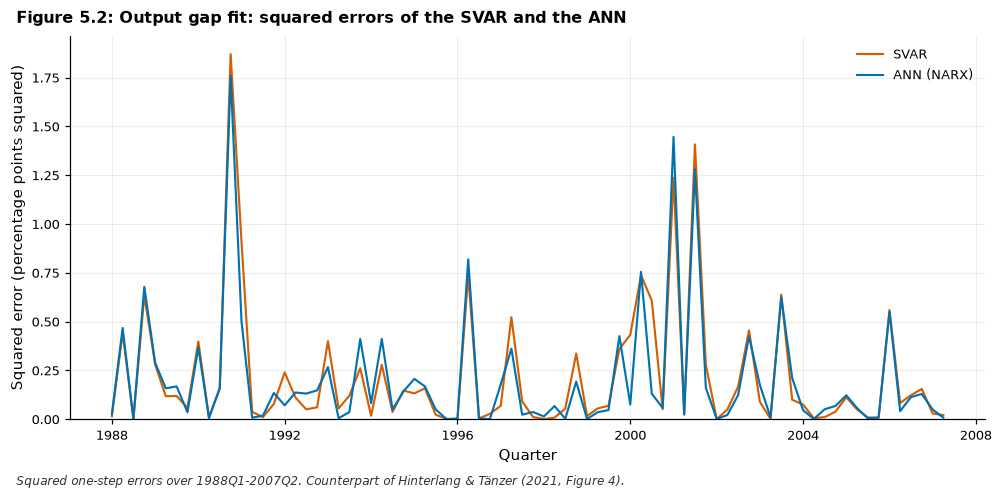

In [26]:
svar_is = svar_fit.loc[fit_narx.index]
fig = plots.squared_errors(
    {"SVAR": squared(svar_is, "y"), "ANN (NARX)": squared(fit_narx, "y")}
)
nb.figure(
    fig,
    "in_sample_se_output_gap",
    "Output gap fit: squared errors of the SVAR and the ANN",
    note=(
        f"Squared one-step errors over {fit_narx.index[0]}-{fit_narx.index[-1]}. Counterpart of"
        " Hinterlang & Tänzer (2021, Figure 4)."
    ),
)

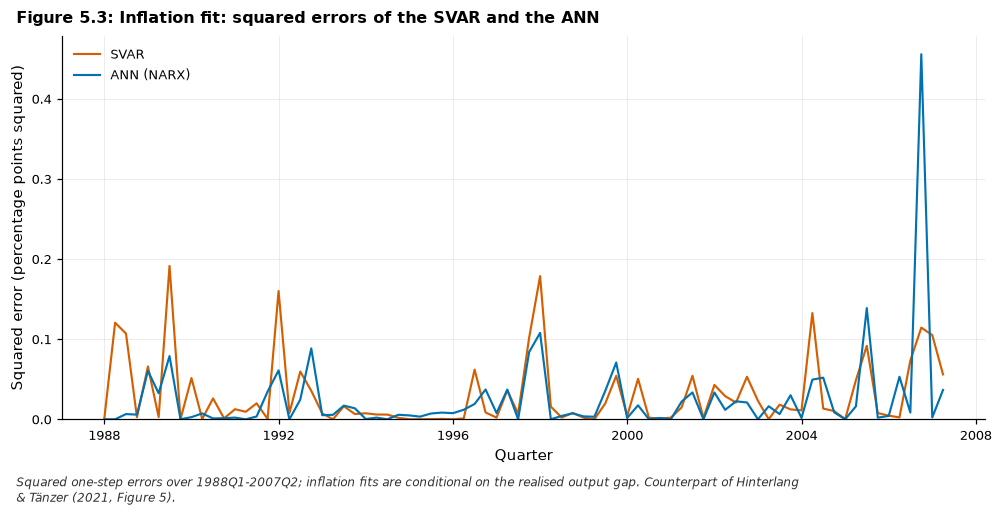

In [27]:
fig = plots.squared_errors(
    {"SVAR": squared(svar_is, "pi"), "ANN (NARX)": squared(fit_narx, "pi")}
)
nb.figure(
    fig,
    "in_sample_se_inflation",
    "Inflation fit: squared errors of the SVAR and the ANN",
    note=(
        f"Squared one-step errors over {fit_narx.index[0]}-{fit_narx.index[-1]}; inflation fits"
        " are conditional on the realised output gap. Counterpart of Hinterlang & Tänzer"
        " (2021, Figure 5)."
    ),
)

## Economy fit: mean squared errors

The following table summarizes the ANN model’s mean squared error for:

- the output-gap equation,
- the inflation equation,
- the overall economy representation, defined here as the simple average of the two equation-specific MSE values.

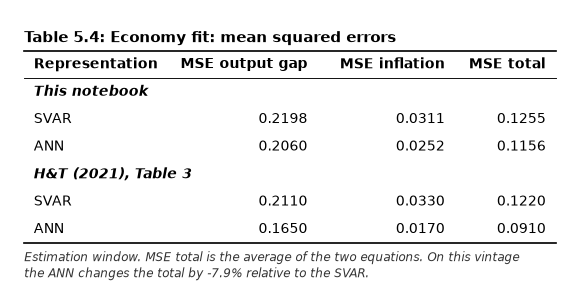

In [28]:
PAPER_TABLE3 = {
    "SVAR": {"MSE output gap": 0.211, "MSE inflation": 0.033, "MSE total": 0.122},
    "ANN": {"MSE output gap": 0.165, "MSE inflation": 0.017, "MSE total": 0.091},
}
mse_table = pd.concat(
    {
        "This notebook": pd.DataFrame({"SVAR": mse_row(svar_is), "ANN": mse_row(fit_narx)}).T,
        "H&T (2021), Table 3": pd.DataFrame(PAPER_TABLE3).T,
    },
    names=["Source", "Representation"],
)
improvement = (
    1.0
    - mse_table.loc[("This notebook", "ANN"), "MSE total"]
    / mse_table.loc[("This notebook", "SVAR"), "MSE total"]
)
nb.table(
    mse_table,
    "economy_fit",
    "Economy fit: mean squared errors",
    float_format="{:.4f}",
    note=(
        "Estimation window. MSE total is the average of the two equations. On this vintage the"
        f" ANN changes the total by {-improvement:+.1%} relative to the SVAR."
    ),
)

## Partial dependence surface plot — ANN economy, inflation

The next figure shows the partial dependence of inflation, $\pi_t$, on last period’s nominal interest rate $i_{t-1}$ and on the output gap, under the restriction

$$
y_t = y_{t-1} = y_{t-2},
$$

while marginalizing over lagged inflation by fixing

$$
\pi_{t-1} = \pi_{t-2} = \bar{\pi}.
$$

This is a partial dependence visualization of the fitted ANN mapping, not a structural impulse-response object.

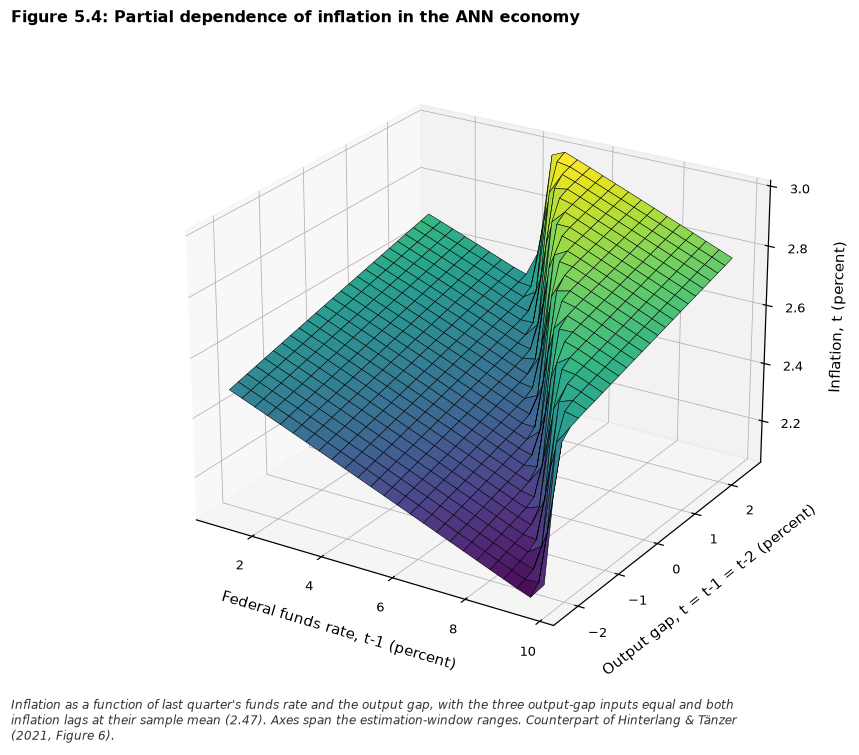

In [29]:
GRID = 25
i_vals = np.linspace(df_train["i"].min(), df_train["i"].max(), GRID)
y_vals = np.linspace(df_train["y"].min(), df_train["y"].max(), GRID)
I, Y = np.meshgrid(i_vals, y_vals)
pi_mean = float(df_train["pi"].mean())

# Inflation network inputs: (y_t, y_{t-1}, y_{t-2}, pi_{t-1}, pi_{t-2}, i_{t-1})
grid = np.column_stack([
    Y.ravel(),
    Y.ravel(),
    Y.ravel(),
    np.full(I.size, pi_mean),
    np.full(I.size, pi_mean),
    I.ravel(),
])
Z = (
    economy.predict_pi(torch.tensor(grid, dtype=DTYPE, device=DEVICE))
    .cpu()
    .numpy()
    .reshape(I.shape)
)

fig = plots.surface(
    I,
    Y,
    Z,
    xlabel="Federal funds rate, t-1 (percent)",
    ylabel="Output gap, t = t-1 = t-2 (percent)",
    zlabel="Inflation, t (percent)",
)
nb.figure(
    fig,
    "partial_dependence_inflation",
    "Partial dependence of inflation in the ANN economy",
    note=(
        "Inflation as a function of last quarter's funds rate and the output gap, with the"
        " three output-gap inputs equal and both inflation lags at their sample mean"
        f" ({pi_mean:.2f}). Axes span the estimation-window ranges. Counterpart of Hinterlang &"
        " Tänzer (2021, Figure 6)."
    ),
)

## Partial dependence surface plot — ANN economy, output gap

The next figure shows the partial dependence of the output gap, $y_t$, on last period’s inflation $\pi_{t-1}$ and nominal interest rate $i_{t-1}$, while holding lagged output gap fixed at its sample mean:

$$
y_{t-1} = \bar{y}.
$$

This again visualizes the fitted ANN mapping rather than a structural or causal policy object.

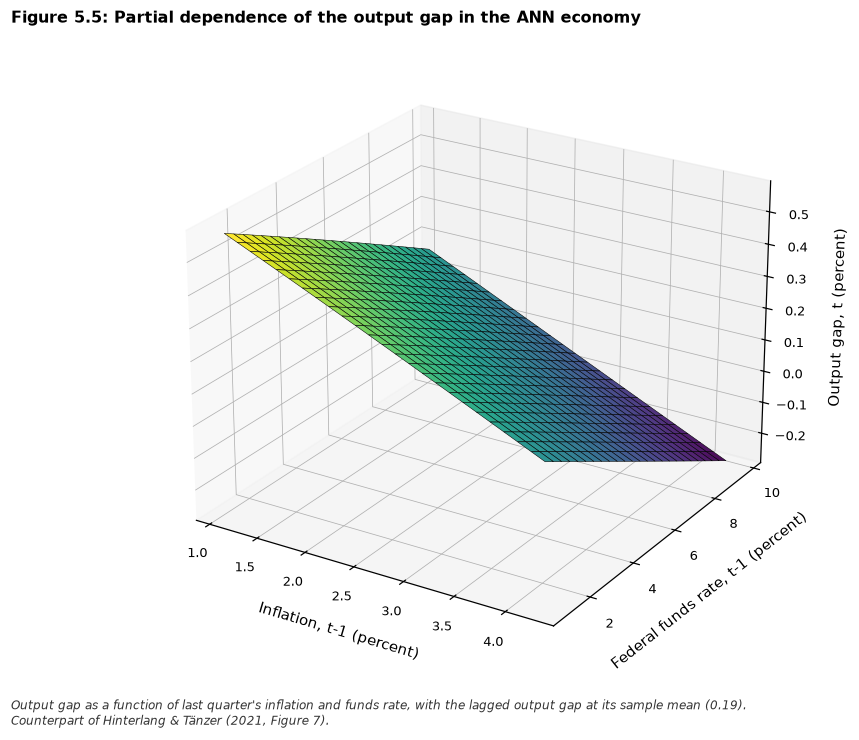

In [30]:
pi_vals = np.linspace(df_train["pi"].min(), df_train["pi"].max(), GRID)
PI, I2 = np.meshgrid(pi_vals, i_vals)
y_mean = float(df_train["y"].mean())

# Output-gap network inputs: (y_{t-1}, pi_{t-1}, i_{t-1})
grid = np.column_stack([np.full(PI.size, y_mean), PI.ravel(), I2.ravel()])
Z = (
    economy.predict_y(torch.tensor(grid, dtype=DTYPE, device=DEVICE))
    .cpu()
    .numpy()
    .reshape(PI.shape)
)

fig = plots.surface(
    PI,
    I2,
    Z,
    xlabel="Inflation, t-1 (percent)",
    ylabel="Federal funds rate, t-1 (percent)",
    zlabel="Output gap, t (percent)",
)
nb.figure(
    fig,
    "partial_dependence_output_gap",
    "Partial dependence of the output gap in the ANN economy",
    note=(
        "Output gap as a function of last quarter's inflation and funds rate, with the lagged"
        f" output gap at its sample mean ({y_mean:.2f}). Counterpart of Hinterlang & Tänzer"
        " (2021, Figure 7)."
    ),
)

## Out-of-Sample ANN Fit — One-Step Actual vs Predicted Values (NARX)

To evaluate the nonlinear environment outside the estimation sample, we next generate one-step out-of-sample predictions for the NARX specification over the post-2007 period.

This evaluation reuses the retained output-gap and inflation networks selected by the hidden-unit search and fitted by Levenberg–Marquardt. Thus, the architecture, fitted weights, and equation-specific scaling objects are identical to those used in the training section. The only change is that the design matrices are now rebuilt over the out-of-sample period.

Because the NARX equations are evaluated directly on observed out-of-sample regressors, this is a one-step conditional out-of-sample assessment rather than a recursive simulation.

The fits below come from the same call that produced the in-sample values: the restricted design is
built on the whole panel, so every out-of-sample quarter from 2007Q3 uses realised lags, the inputs
are scaled with the scalers retained from the estimation window, and predictions are mapped back to
percent. The inflation fit is conditional on the realised contemporaneous output gap, as in the linear
notebooks.

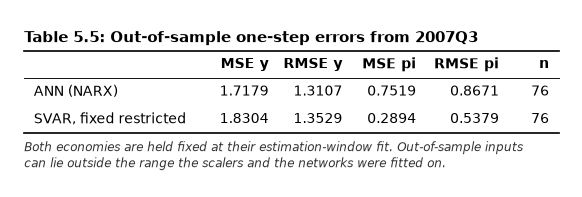

In [31]:
oos = fit_all.loc[cfg.oos_start :].join(svar_fit[["y_hat", "pi_hat"]].add_suffix("_svar"))
assert not oos.isna().any().any()

oos_metrics = pd.DataFrame({
    "ANN (NARX)": lin.error_metrics(oos),
    "SVAR, fixed restricted": lin.error_metrics(oos, "y_hat_svar", "pi_hat_svar"),
}).T
oos_metrics["n"] = oos_metrics["n"].astype(int)
nb.table(
    oos_metrics,
    "oos_error_metrics",
    f"Out-of-sample one-step errors from {cfg.oos_start}",
    float_format="{:.4f}",
    note=(
        "Both economies are held fixed at their estimation-window fit. Out-of-sample inputs can"
        " lie outside the range the scalers and the networks were fitted on."
    ),
)

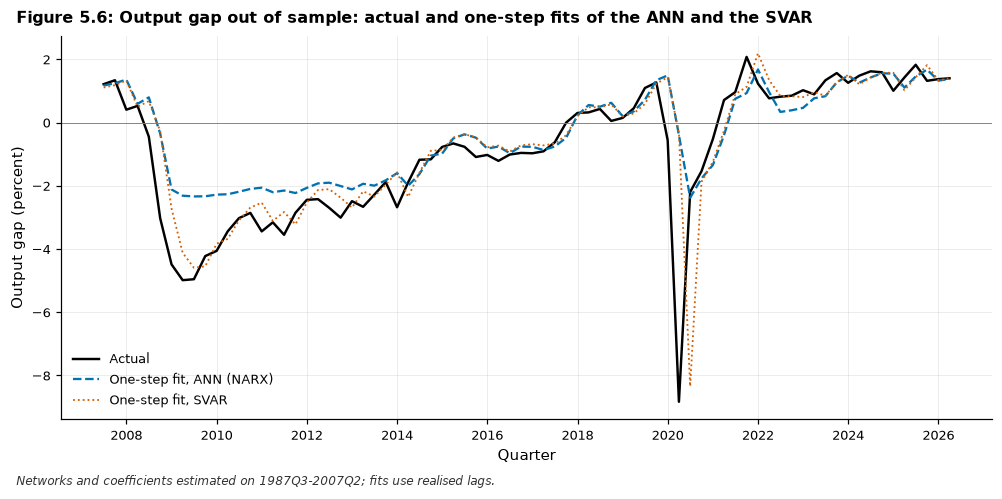

In [32]:
fig = plots.actual_vs_fit(
    oos, "y", {"One-step fit, ANN (NARX)": "y_hat", "One-step fit, SVAR": "y_hat_svar"}
)
nb.figure(
    fig,
    "oos_output_gap",
    "Output gap out of sample: actual and one-step fits of the ANN and the SVAR",
    note=(
        f"Networks and coefficients estimated on {cfg.train_start}-{cfg.train_end}; fits use"
        " realised lags."
    ),
)

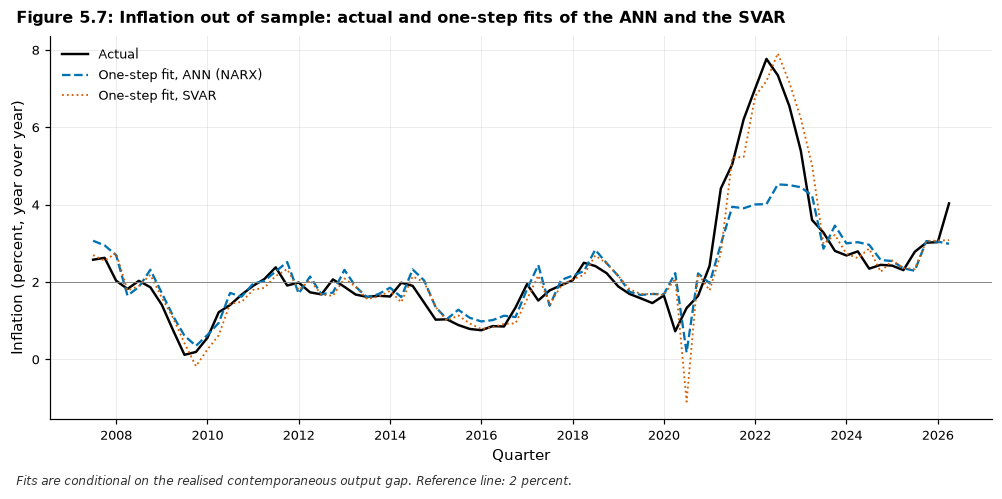

In [33]:
fig = plots.actual_vs_fit(
    oos, "pi", {"One-step fit, ANN (NARX)": "pi_hat", "One-step fit, SVAR": "pi_hat_svar"}
)
nb.figure(
    fig,
    "oos_inflation",
    "Inflation out of sample: actual and one-step fits of the ANN and the SVAR",
    note=(
        "Fits are conditional on the realised contemporaneous output gap. Reference line: 2"
        " percent."
    ),
)

# References (APA)

## Software
1. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (v3.0.0). Zenodo. https://doi.org/10.5281/zenodo.17635942

2. The pandas development team. (2026). pandas-dev/pandas: Pandas (v3.0.1). Zenodo. https://doi.org/10.5281/zenodo.18675244

3. Python Software Foundation. (2025). Python (Version 3.13.7) [Computer software]. Python Software Foundation. https://www.python.org/

4. The Matplotlib Development Team. (2025). Matplotlib: Visualization with Python (v3.10.8). Zenodo. https://doi.org/10.5281/zenodo.17595503

5. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

6. Thomas, Kluyver & Benjamin, Ragan-Kelley & Fernando, Perez & Brian, Granger & Matthias, Bussonnier & Jonathan, Frederic & Kyle, Kelley & Jessica, Hamrick & Jason, Grout & Sylvain, Corlay & Paul, Ivanov & Damian, Avila & Safia, Abdalla & Carol, Willing & Team, Jupyter. (2016). Jupyter Notebooks – a publishing format for reproducible computational workflows. 10.3233/978-1-61499-649-1-87.

7. Ansel, J., Yang, E., He, H., Gimelshein, N., Jain, A., Voznesensky, M., Bao, B., Bell, P., Berard, D., Burovski, E., Chauhan, G., Chourdia, A., Constable, W., Desmaison, A., DeVito, Z., Ellison, E., Feng, W., Gong, J., Gschwind, M., Hirsh, B., Huang, S., Kalambarkar, K., Kirsch, L., Lazos, M., Lezcano, M., Liang, Y., Liang, J., Lu, Y., Luk, C., Maher, B., Pan, Y., Puhrsch, C., Reso, M., Saroufim, M., Siraichi, M. Y., Suk, H., Suo, M., Tillet, P., Wang, E., Wang, X., Wen, W., Zhang, S., Zhao, X., Zhou, K., Zou, R., Mathews, A., Chanan, G., Wu, P., & Chintala, S. (2024). PyTorch 2: Faster Machine Learning Through Dynamic Python Bytecode Transformation and Graph Compilation [Conference paper]. 29th ACM International Conference on Architectural Support for Programming Languages and Operating Systems, Volume 2 (ASPLOS '24). https://doi.org/10.1145/3620665.3640366

## Papers & Books
1. Chen, S., & Billings, S. A. (1992). Neural networks for nonlinear dynamic system modelling and identification. *International Journal of Control*, 56(2), 319–346. https://doi.org/10.1080/00207179208934317

2. Narendra, K. S., & Parthasarathy, K. (1990). Identification and control of dynamical systems using neural networks. *IEEE transactions on neural networks*, 1(1), 4–27. https://doi.org/10.1109/72.80202

3. Raiko, T., Valpola, H., & LeCun, Y. (2012). Deep Learning Made Easier by Linear Transformations in Perceptrons. *International Conference on Artificial Intelligence and Statistics*.

4. Nguyen, D., & Widrow, B. (1990). Neural Network for Self-Learning Control Systems. *Control Systems Magazine*, IEEE. 10. 18 - 23. https://doi.org/10.1109/37.55119.

5. Levenberg, K. (1944) A Method for the Solution of Certain Non-Linear Problems in Least Squares. *Quarterly of Applied Mathematics*, 2, 164-168. https://doi.org/10.1090/qam/10666

6. Marquardt, D. W. (1963). An Algorithm for Least-Squares Estimation of Nonlinear Parameters. *Journal of the Society for Industrial and Applied Mathematics*, 11(2), 431–441. http://www.jstor.org/stable/2098941

7. Aras, S., & Kocakoç, I. D. (2016). A new model selection strategy in time series forecasting with artificial neural networks. *IHTS. Neurocomputing.* 174. 10.1016/j.neucom.2015.10.036.

8. White, H. (1988). Economic prediction using neural networks: The case of IBM daily stock returns. *Proceedings of the IEEE International Conference on Neural Networks*, 2, 451–458.

9. Swanson, N. R., & White, H. (1997). A model selection approach to assessing the information in the term structure using linear models and artificial neural networks. *Journal of Business & Economic Statistics*, 15(4), 370–386.

10. Durbin, J., & Koopman, S. J. (2001). Time Series Analysis by State Space Methods. https://doi.org/10.1093/acprof:oso/9780199641178.001.0001

11. Fraccaro, M., & Sønderby, S., & Paquet, U., & Winther, O. (2016). Sequential Neural Models with Stochastic Layers. https://doi.org/10.48550/arXiv.1605.07571

12. Krishnan, R. G., Shalit, U., Sontag, D., (2017). Structured Inference Networks for Nonlinear State Space Models. https://doi.org/10.48550/arXiv.1609.09869

13. Rangapuram, S. S., Seeger, M., Gasthaus, J., Stella, L., Yuyang, Wang., Januschowski, T. (2018). Deep State Space Models for Time Series Forecasting. *NIPS'18: Proceedings of the 32nd International Conference on Neural Information Processing Systems*, 7796-7805.

14. Elfwing, S., & Uchibe, Eiji & Doya, Kenji. (2018). Unbounded Output Networks for Classification. https://doi.org/10.48550/arXiv.1807.09443

15. Ramachandran, P., Zoph, B., & Le, Q.V. (2018). Searching for Activation Functions. *ArXiv*, https://doi.org/abs/1710.05941

16. Saxe, A., & Mcclelland, J., & Ganguli, S. (2013). Exact solutions to the nonlinear dynamics of learning in deep linear neural networks. https://doi.org/10.48550/arXiv.1312.6120

17. Hu, W., Xiao, L., & Pennington, J. (2020). Provable Benefit of Orthogonal Initialization in Optimizing Deep Linear Networks. *ArXiv*, https://doi.org/abs/2001.05992

18. Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. *International Conference on Artificial Intelligence and Statistics*.

19. Loshchilov, I., & Hutter, F. (2017). Decoupled Weight Decay Regularization. *International Conference on Learning Representations*. https://doi.org/10.48550/arXiv.1711.05101

# Export

The last cell converts this notebook to PDF in the shared `documents/` directory. A kernel can only
convert the copy saved on disk, so the cell waits briefly for the editor to save; if the file is still
behind, it writes nothing and asks you to save and run it again.

In [34]:
nb.export_pdf()

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_97606/281924391.py:1: UserWarning: 05_nonlinear_narx.ipynb on disk does not yet contain this run's outputs, so no PDF was written. Save the notebook and run this cell again.
  nb.export_pdf()
